In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.stats import gaussian_kde
import hashlib

In [2]:
PLOT_FIGURES = False

In [3]:
### !!! ###
file_path = 'inference_total_0.25_all_2.csv'

# Read the CSV file
data = pd.read_csv(file_path, delimiter=";")

# Remove '[' and ']' characters and replace line feed with space character in Text fields
data.replace({r'[\[\]]': '', r'\n': ' ', r'\'': '', r'None': ''}, regex=True, inplace=True)

# Transpose the DataFrame
data = data.T

print(f"The data shape is {data.shape}")

# Reset the index
data.reset_index(drop=False, inplace=True)

# Set the new column names
data.columns = ['Image'] + [f'Text_{i+1}' for i in range(data.shape[1] - 1)]

# Set the "Image" column as the index
#data.set_index('Image', inplace=True)

The data shape is (930, 29)


In [4]:
data

,Image,Text_1,Text_2,Text_3,Text_4,Text_5,Text_6,Text_7,Text_8,Text_9,...,Text_20,Text_21,Text_22,Text_23,Text_24,Text_25,Text_26,Text_27,Text_28,Text_29
0,6CB4EFC6-68FA-4CD5-940C-BEFA8DAFE9A7.jpeg,Findings suggestive of multifocal pneumonia. ...,1. Diffuse pulmonary edema. 2. Right upper l...,1. Multifocal pneumonia. 2. Moderate cardiom...,"1. Diffuse bilateral airspace opacities, conc...",Findings suggesting moderate pulmonary edema. ...,Findings most suggestive of pulmonary edema. ...,1. Findings suggestive of pulmonary edema. 2....,Findings suggesting moderate pulmonary edema.,"1. Diffuse bilateral airspace opacities, conc...",...,1. Worsening pulmonary edema. 2. Right upper...,Findings suggesting moderate pulmonary edema. ...,1. Interval development of mild pulmonary ede...,1. Interval development of mild pulmonary ede...,1. Diffuse bilateral pulmonary edema. 2. Rig...,Findings suggesting moderate pulmonary edema. ...,"1. Bilateral upper lobe consolidations, right...",1. Interval development of mild pulmonary ede...,Findings suggestive of multifocal pneumonia. ...,1. Worsening pulmonary edema. 2. Right upper...
1,1-s2.0-S1341321X20301124-gr3_lrg-e.png,1. Endotracheal tube terminates approximately...,1. Endotracheal tube terminates approximately...,1. Interval placement of a right internal jug...,1. Right internal jugular central venous cath...,1. Endotracheal tube terminates approximately...,1. No evidence of pneumonia. 2. Mild pulmona...,1. Endotracheal tube terminates approximately...,1. Endotracheal tube terminates approximately...,1. No evidence of pneumothorax. 2. Bilateral...,...,1. Endotracheal tube terminates approximately...,1. Endotracheal tube terminates approximately...,1. Low lung volumes with bibasilar atelectasi...,1. Endotracheal tube terminates 4.5 cm above ...,1. Low lung volumes with bibasilar atelectasi...,1. No evidence of pneumothorax. 2. No eviden...,1. Endotracheal tube terminates approximately...,1. Endotracheal tube terminates approximately...,1. No evidence of pneumonia. 2. Bilateral pl...,1. No evidence of pneumothorax. 2. Bilateral...
2,180e8fe6c27840acf913013a23328a_jumbo.jpeg,No acute cardiopulmonary process.,Findings concerning for right middle lobe pneu...,Findings concerning for right lower lobe pneum...,Findings concerning for right middle lobe pneu...,1. No evidence of pneumonia. 2. Mild pulmona...,No acute cardiopulmonary process.,Findings concerning for right middle lobe pneu...,No acute cardiopulmonary process.,No acute cardiopulmonary process.,...,No acute cardiopulmonary process.,1. No evidence of pneumonia. 2. Findings sug...,No acute cardiopulmonary process.,1. No evidence of pneumonia. 2. No evidence ...,1. No acute cardiopulmonary process. 2. Find...,No acute cardiopulmonary process.,No acute cardiopulmonary process.,1. No evidence of pneumothorax. 2. No acute ...,1. No evidence of pneumonia. 2. Findings sug...,No acute cardiopulmonary process.
3,66298CBF-6F10-42D5-A688-741F6AC84A76.jpeg,No acute cardiopulmonary process.,1. No evidence of pneumothorax. 2. No eviden...,No evidence of acute cardiopulmonary process.,1. Endotracheal tube terminates approximately...,No acute cardiopulmonary process.,No acute cardiopulmonary process.,No evidence of acute cardiopulmonary process.,No acute cardiopulmonary process.,No evidence of acute cardiopulmonary process.,...,No acute cardiopulmonary process.,No acute cardiopulmonary process.,No acute cardiopulmonary process.,No acute cardiopulmonary process.,No evidence of acute cardiopulmonary process.,No acute cardiopulmonary process.,No evidence of acute cardiopulmonary process.,No acute cardiopulmonary process.,No acute cardiopulmonary process.,No evidence of acute cardiopulmonary process.
4,16708_4_1.jpg,No acute cardiopulmonary process.,No acute cardiopulmonary process.,No acute cardiopulmonary process.,No acute cardiopulmonary process.,No evidence of acute cardiopulmonary process.,No acute cardiopulmonary process.,No acute cardiopulmonary p

In [5]:
from transformers import BertTokenizer, BertModel
import torch

# Load BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased', output_hidden_states=True)

def get_bert_embeddings(text):
    encoded_input = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=512)
    
    with torch.no_grad():
        outputs = model(**encoded_input)
        
    embeddings = outputs.last_hidden_state
    attention_mask = encoded_input['attention_mask']
    mask = attention_mask.unsqueeze(-1).expand(embeddings.size()).float()
    sum_embeddings = torch.sum(embeddings * mask, 1)
    sum_mask = torch.clamp(mask.sum(1), min=1e-9)
    mean_embeddings = sum_embeddings / sum_mask
    return mean_embeddings[0].numpy()

def generate_unique_id(prompt):
    """Generates a unique hash for a given prompt."""
    return hashlib.sha256(prompt.encode('utf-8')).hexdigest()


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

/Users/ozgur/miniforge3/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [6]:
# Initialize DataFrame to store results
columns = ['Image', 'Num_Clusters', 'Cluster_Areas', 'Convex_Hull_Area']
results_df = pd.DataFrame(columns=columns)

In [7]:
data

,Image,Text_1,Text_2,Text_3,Text_4,Text_5,Text_6,Text_7,Text_8,Text_9,...,Text_20,Text_21,Text_22,Text_23,Text_24,Text_25,Text_26,Text_27,Text_28,Text_29
0,6CB4EFC6-68FA-4CD5-940C-BEFA8DAFE9A7.jpeg,Findings suggestive of multifocal pneumonia. ...,1. Diffuse pulmonary edema. 2. Right upper l...,1. Multifocal pneumonia. 2. Moderate cardiom...,"1. Diffuse bilateral airspace opacities, conc...",Findings suggesting moderate pulmonary edema. ...,Findings most suggestive of pulmonary edema. ...,1. Findings suggestive of pulmonary edema. 2....,Findings suggesting moderate pulmonary edema.,"1. Diffuse bilateral airspace opacities, conc...",...,1. Worsening pulmonary edema. 2. Right upper...,Findings suggesting moderate pulmonary edema. ...,1. Interval development of mild pulmonary ede...,1. Interval development of mild pulmonary ede...,1. Diffuse bilateral pulmonary edema. 2. Rig...,Findings suggesting moderate pulmonary edema. ...,"1. Bilateral upper lobe consolidations, right...",1. Interval development of mild pulmonary ede...,Findings suggestive of multifocal pneumonia. ...,1. Worsening pulmonary edema. 2. Right upper...
1,1-s2.0-S1341321X20301124-gr3_lrg-e.png,1. Endotracheal tube terminates approximately...,1. Endotracheal tube terminates approximately...,1. Interval placement of a right internal jug...,1. Right internal jugular central venous cath...,1. Endotracheal tube terminates approximately...,1. No evidence of pneumonia. 2. Mild pulmona...,1. Endotracheal tube terminates approximately...,1. Endotracheal tube terminates approximately...,1. No evidence of pneumothorax. 2. Bilateral...,...,1. Endotracheal tube terminates approximately...,1. Endotracheal tube terminates approximately...,1. Low lung volumes with bibasilar atelectasi...,1. Endotracheal tube terminates 4.5 cm above ...,1. Low lung volumes with bibasilar atelectasi...,1. No evidence of pneumothorax. 2. No eviden...,1. Endotracheal tube terminates approximately...,1. Endotracheal tube terminates approximately...,1. No evidence of pneumonia. 2. Bilateral pl...,1. No evidence of pneumothorax. 2. Bilateral...
2,180e8fe6c27840acf913013a23328a_jumbo.jpeg,No acute cardiopulmonary process.,Findings concerning for right middle lobe pneu...,Findings concerning for right lower lobe pneum...,Findings concerning for right middle lobe pneu...,1. No evidence of pneumonia. 2. Mild pulmona...,No acute cardiopulmonary process.,Findings concerning for right middle lobe pneu...,No acute cardiopulmonary process.,No acute cardiopulmonary process.,...,No acute cardiopulmonary process.,1. No evidence of pneumonia. 2. Findings sug...,No acute cardiopulmonary process.,1. No evidence of pneumonia. 2. No evidence ...,1. No acute cardiopulmonary process. 2. Find...,No acute cardiopulmonary process.,No acute cardiopulmonary process.,1. No evidence of pneumothorax. 2. No acute ...,1. No evidence of pneumonia. 2. Findings sug...,No acute cardiopulmonary process.
3,66298CBF-6F10-42D5-A688-741F6AC84A76.jpeg,No acute cardiopulmonary process.,1. No evidence of pneumothorax. 2. No eviden...,No evidence of acute cardiopulmonary process.,1. Endotracheal tube terminates approximately...,No acute cardiopulmonary process.,No acute cardiopulmonary process.,No evidence of acute cardiopulmonary process.,No acute cardiopulmonary process.,No evidence of acute cardiopulmonary process.,...,No acute cardiopulmonary process.,No acute cardiopulmonary process.,No acute cardiopulmonary process.,No acute cardiopulmonary process.,No evidence of acute cardiopulmonary process.,No acute cardiopulmonary process.,No evidence of acute cardiopulmonary process.,No acute cardiopulmonary process.,No acute cardiopulmonary process.,No evidence of acute cardiopulmonary process.
4,16708_4_1.jpg,No acute cardiopulmonary process.,No acute cardiopulmonary process.,No acute cardiopulmonary process.,No acute cardiopulmonary process.,No evidence of acute cardiopulmonary process.,No acute cardiopulmonary process.,No acute cardiopulmonary p

In [8]:
# Initialize an empty list to collect rows
rows = []

for image, row in tqdm(data.iterrows(), total=data.shape[0]):
    row_dict = {'Image': row['Image']}
    texts = row.values[1:]

    embeddings = np.array([get_bert_embeddings(text) for text in texts if pd.notnull(text)])

    if embeddings.shape[0] < 10:
        row_dict['Convex_Hull_Area'] = None
        row_dict['Num_Clusters'] = 0
        row_dict['Cluster_Areas'] = []
        rows.append(row_dict)
        continue

    # Dimensionality Reduction
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)

    if embeddings_2d.shape[0] < 15:
        row_dict['Convex_Hull_Area'] = None
        row_dict['Num_Clusters'] = 0
        row_dict['Cluster_Areas'] = []
        rows.append(row_dict)
        continue

    # Clustering with DBSCAN
    dbscan = DBSCAN(eps=7.0, min_samples=3)
    labels = dbscan.fit_predict(embeddings_2d)

    unique_labels = set(labels)
    hull_volumes = []
    total_hull_area = 0
    num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    
    for label in unique_labels:
        if label == -1:
            continue
        cluster_indices = [idx for idx, l in enumerate(labels) if l == label]
        cluster_points = embeddings_2d[cluster_indices]

        if len(np.unique(cluster_points, axis=0)) > 3:
            hull = ConvexHull(cluster_points)
            hull_area = hull.volume
            hull_volumes.append(hull_area)
            total_hull_area += hull_area

    if PLOT_FIGURES:
        plt.figure(figsize=(8, 6))
        plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels, cmap='viridis', zorder=10, s=50)
        
        # Calculate the point density
        x = embeddings_2d[:, 0]
        y = embeddings_2d[:, 1]
        xy = np.vstack([x, y])
        z = gaussian_kde(xy)(xy)

        # Create a contour plot
        xi, yi = np.linspace(x.min(), x.max(), 100), np.linspace(y.min(), y.max(), 100)
        xi, yi = np.meshgrid(xi, yi)
        zi = gaussian_kde(xy)(np.vstack([xi.flatten(), yi.flatten()]))

        plt.contourf(xi, yi, zi.reshape(xi.shape), levels=15, cmap='viridis')
        plt.colorbar(label='Density')

        plt.scatter(x, y, c=labels, edgecolor='k', cmap='viridis', zorder=10, s=50)
        for simplex in hull.simplices:
            plt.plot(cluster_points[simplex, 0], cluster_points[simplex, 1], 'w--')

    if PLOT_FIGURES:
        hull_volumes_str = ', '.join(f'Cluster {label}: {volume:.2f}' for label, volume in zip(unique_labels, hull_volumes) if label != -1)
        plt.grid(True)
        plt.savefig(f"img/{image}-hull.pdf",bbox_inches='tight')
        plt.show()

    row_dict['Convex_Hull_Area'] = total_hull_area
    row_dict['Num_Clusters'] = num_clusters
    row_dict['Cluster_Areas'] = hull_volumes
    rows.append(row_dict)

  0%|          | 0/930 [00:00<?, ?it/s]

In [9]:
# Concatenate rows into a DataFrame
results_df = pd.concat([results_df, pd.DataFrame(rows)], ignore_index=True)

results_df

/var/folders/rh/1c0lrj_x0x956417g86lc4ph0000gn/T/ipykernel_35665/85570381.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, pd.DataFrame(rows)], ignore_index=True)


,Image,Num_Clusters,Cluster_Areas,Convex_Hull_Area
0,6CB4EFC6-68FA-4CD5-940C-BEFA8DAFE9A7.jpeg,1,[23.63623741793659],23.636237
1,1-s2.0-S1341321X20301124-gr3_lrg-e.png,1,[18.27328174443453],18.273282
2,180e8fe6c27840acf913013a23328a_jumbo.jpeg,1,[21.303962915280046],21.303963
3,66298CBF-6F10-42D5-A688-741F6AC84A76.jpeg,1,[11.228109955279278],11.228110
4,16708_4_1.jpg,1,[9.567705380726892],9.567705
...,...,...,...,...
925,covid-19-pneumonia-15-PA.jpg,1,[16.547808470510716],16.547808
926,1-s2.0-S1684118220300608-main.pdf-002.jpg,1,[17.347741100413987],17.347741
927,article_river_1a00a3c07ea311eab70491c6fb93d336...,1,[18.96427369665038],18.964274
928,430f21e7.jpg,1,[4.572313976650383],4.572314


In [10]:
# Concatenate rows into a DataFrame
results_df = pd.concat([results_df, pd.DataFrame(rows)], ignore_index=True)

results_df

results_df.to_csv('results.csv', index=False)

In [11]:
results_df = pd.read_csv('results.csv')
results_df

,Image,Num_Clusters,Cluster_Areas,Convex_Hull_Area
0,6CB4EFC6-68FA-4CD5-940C-BEFA8DAFE9A7.jpeg,1,[23.63623741793659],23.636237
1,1-s2.0-S1341321X20301124-gr3_lrg-e.png,1,[18.27328174443453],18.273282
2,180e8fe6c27840acf913013a23328a_jumbo.jpeg,1,[21.303962915280046],21.303963
3,66298CBF-6F10-42D5-A688-741F6AC84A76.jpeg,1,[11.228109955279278],11.228110
4,16708_4_1.jpg,1,[9.567705380726892],9.567705
...,...,...,...,...
1855,covid-19-pneumonia-15-PA.jpg,1,[16.547808470510716],16.547808
1856,1-s2.0-S1684118220300608-main.pdf-002.jpg,1,[17.347741100413987],17.347741
1857,article_river_1a00a3c07ea311eab70491c6fb93d336...,1,[18.96427369665038],18.964274
1858,430f21e7.jpg,1,[4.572313976650383],4.572314


In [12]:
# Define a function to plot clusters and convex hulls
def plot_clusters(embeddings_2d, labels, image, ax, uncertainty_value):
    unique_labels = set(labels)
    ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='r', zorder=10, s=50)
    for label in unique_labels:
        if label == -1:
            continue
        cluster_indices = [idx for idx, l in enumerate(labels) if l == label]
        cluster_points = embeddings_2d[cluster_indices]
        if len(np.unique(cluster_points, axis=0)) > 2:
            hull = ConvexHull(cluster_points)
            for simplex in hull.simplices:
                ax.plot(cluster_points[simplex, 0], cluster_points[simplex, 1], 'k--')
            ax.fill(cluster_points[hull.vertices, 0], cluster_points[hull.vertices, 1], 'b', alpha=0.1)
            ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color='b', zorder=10)
            ax.scatter(cluster_points[:, 0], cluster_points[:, 1], color='r', zorder=20)
            
            # Calculate the point density
            x = embeddings_2d[:, 0]
            y = embeddings_2d[:, 1]
            xy = np.vstack([x, y])
            z = gaussian_kde(xy)(xy)

            # Create a contour plot
            xi, yi = np.linspace(-8.0, 5.0, 100), np.linspace(-8.0, 5.0, 100)
            xi, yi = np.meshgrid(xi, yi)
            zi = gaussian_kde(xy)(np.vstack([xi.flatten(), yi.flatten()]))

            ax.contourf(xi, yi, zi.reshape(xi.shape), levels=15, cmap='viridis')
            #ax.set_colorbar(label='Density')
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=8)

    #ax.set_title(f'Image: {image}\nUncertainty: {uncertainty_value:.2f}\nHull value:{hull.volume}')
    ax.grid(True)
    ax.set_xlim([-8.0, 5.0])
    ax.set_ylim([-8, 5])

In [13]:
def plot_clusters_plt(embeddings_2d, labels, image, uncertainty_value, fig_name):
    unique_labels = set(labels)
    
    # Initialize a new figure
    plt.figure(figsize=(8, 6))
    
    # Plot all points
    plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='r', zorder=10, s=50, label='Points')

    for label in unique_labels:
        if label == -1:
            continue
        cluster_indices = [idx for idx, l in enumerate(labels) if l == label]
        cluster_points = embeddings_2d[cluster_indices]

        if len(np.unique(cluster_points, axis=0)) > 3:
            hull = ConvexHull(cluster_points)
            
            for simplex in hull.simplices:
                plt.plot(cluster_points[simplex, 0], cluster_points[simplex, 1], 'k--')
            
            plt.fill(cluster_points[hull.vertices, 0], cluster_points[hull.vertices, 1], 'b', alpha=0.1, label='Convex Hull')
            
            # Scatter the cluster points
            plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color='b', zorder=20, label='Cluster Points')

    # Create a density plot
    try:
        x = embeddings_2d[:, 0]
        y = embeddings_2d[:, 1]
        xy = np.vstack([x, y])
        z = gaussian_kde(xy)(xy)

        xi, yi = np.linspace(-8.0, 5.0, 100), np.linspace(-8.0, 5.0, 200)
        xi, yi = np.meshgrid(xi, yi)
        zi = gaussian_kde(xy)(np.vstack([xi.flatten(), yi.flatten()]))

        plt.contourf(xi, yi, zi.reshape(xi.shape), levels=15, cmap='viridis', alpha=0.5)
    except:
        print("An exception occurred")
    

    # Set plot details
    # plt.title(f'Image: {image}\nUncertainty: {uncertainty_value:.2f}')
    plt.grid(True)
    plt.xlim([-0.1, 1.1])
    plt.ylim([-0.1, 1.1])
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(fig_name, bbox_inches='tight')
    # Show the plot
    plt.show()

# Example usage:
# plot_clusters(embeddings_2d, labels, "example_image.png", 1.23)


In [14]:
def average_cluster_areas(cluster_areas):
    cluster_areas = [eval(area) for area in cluster_areas]  # Convert strings to lists
    avg_areas = [sum(area) / len(area) for area in zip(*cluster_areas)]
    return avg_areas

# Group by 'Image' and calculate the mean for numeric columns
numeric_columns = ['Num_Clusters', 'Convex_Hull_Area']
averaged_numeric = results_df.groupby('Image')[numeric_columns].mean()

# Handle cluster areas separately
cluster_areas_averaged = results_df.groupby('Image')['Cluster_Areas'].apply(average_cluster_areas)

# Combine the results
results_df = pd.concat([averaged_numeric, cluster_areas_averaged], axis=1).reset_index()
results_df

,Image,Num_Clusters,Convex_Hull_Area,Cluster_Areas
0,000001-1.jpg,1.0,2.639844e+01,[26.398441547673208]
1,000001-1.png,1.0,1.674359e+01,[16.74359344869947]
2,000001-10.jpg,1.0,1.811903e+01,[18.11903484795215]
3,000001-11.jpg,1.0,2.005623e+01,[20.05622635467627]
4,000001-12.jpg,2.0,5.157770e-07,[5.157770158012087e-07]
...,...,...,...,...
925,wong-0004.jpg,1.0,0.000000e+00,[]
926,wong-0005.jpg,1.0,3.175804e+01,[31.7580358588538]
927,yxppt-2020-02-19_00-51-27_287214-day10.jpg,1.0,3.703742e-12,[3.70374153724186e-12]
928,yxppt-2020-02-19_00-51-27_287214-day12.jpg,1.0,1.855132e+01,[18.551324222612415]


In [15]:
data.query("Image == '565'")

,Image,Text_1,Text_2,Text_3,Text_4,Text_5,Text_6,Text_7,Text_8,Text_9,...,Text_20,Text_21,Text_22,Text_23,Text_24,Text_25,Text_26,Text_27,Text_28,Text_29


In [16]:
data.query("Image == '000001-1.jpg'")

,Image,Text_1,Text_2,Text_3,Text_4,Text_5,Text_6,Text_7,Text_8,Text_9,...,Text_20,Text_21,Text_22,Text_23,Text_24,Text_25,Text_26,Text_27,Text_28,Text_29
519,000001-1.jpg,Multifocal pneumonia.,Multifocal pneumonia.,Multifocal pneumonia.,Multifocal pneumonia.,Moderate pulmonary edema.,Multifocal pneumonia.,1. Multifocal pneumonia. 2. Mild pulmonary e...,1. Multifocal pneumonia. 2. Mild pulmonary e...,Multifocal pneumonia.,...,Findings concerning for multifocal pneumonia.,Multifocal pneumonia.,Multifocal pneumonia.,Moderate pulmonary edema.,"1. Diffuse bilateral airspace opacities, conc...",Multifocal pneumonia.,1. Multifocal pneumonia. 2. Mild pulmonary e...,Findings suggesting mild pulmonary edema.,"1. Diffuse bilateral airspace opacities, whic...",Findings compatible with multifocal pneumonia.


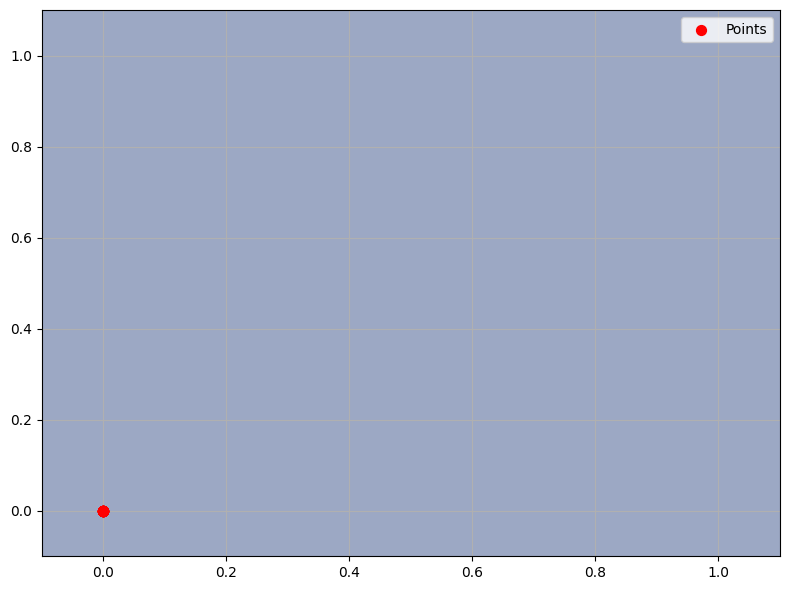

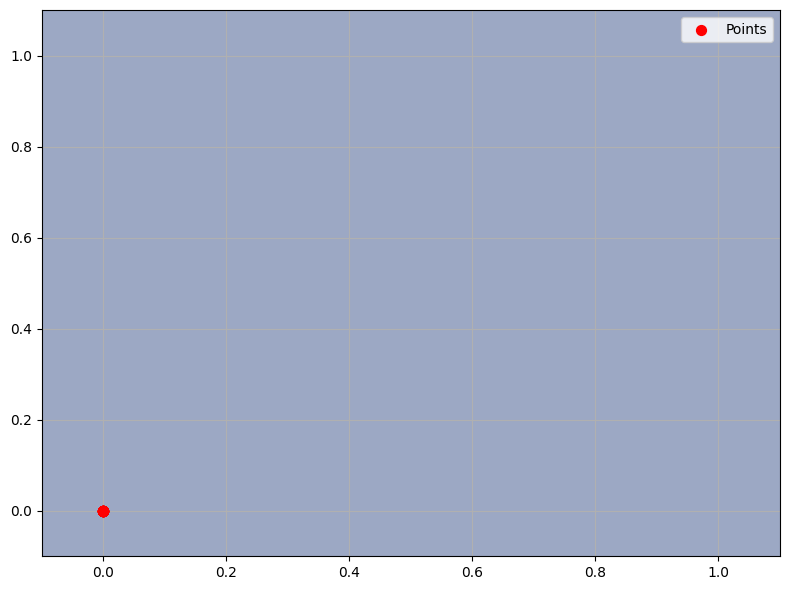

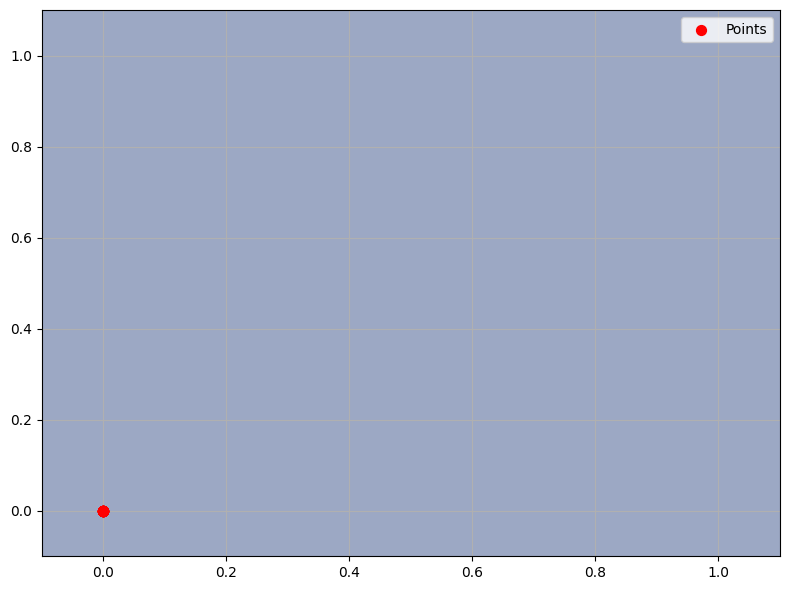

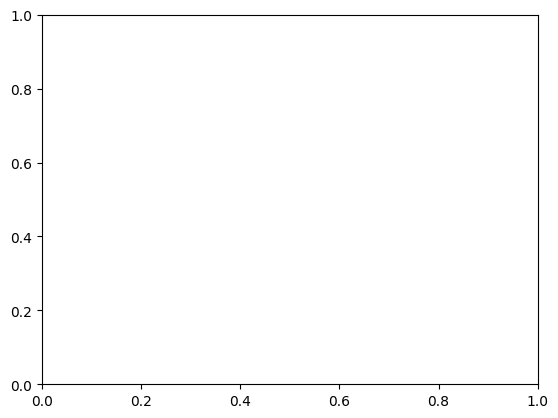

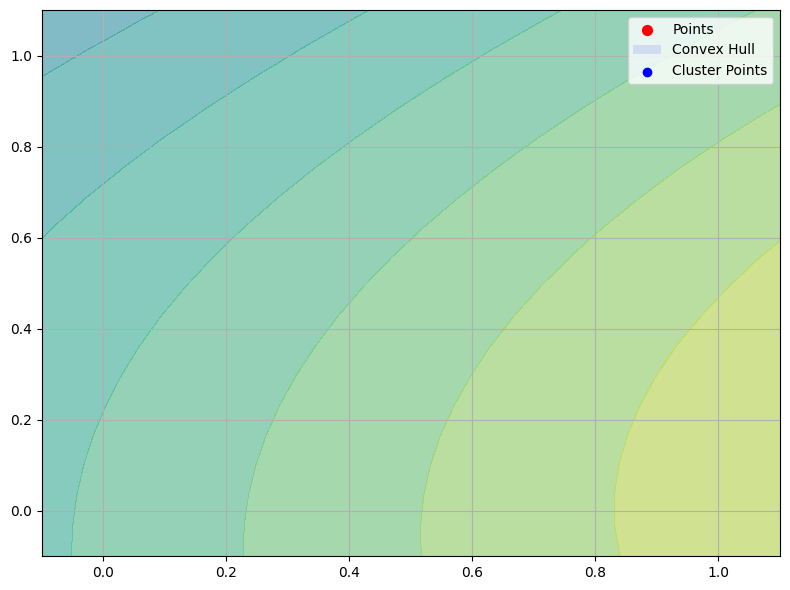

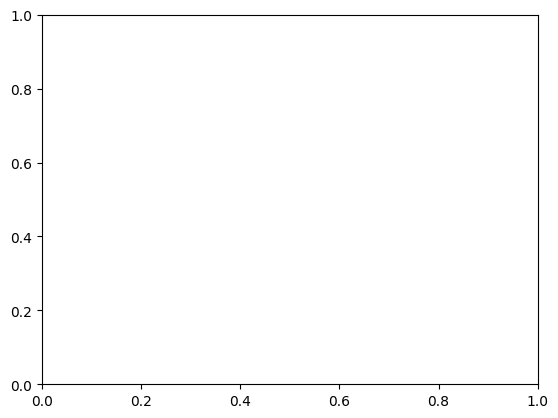

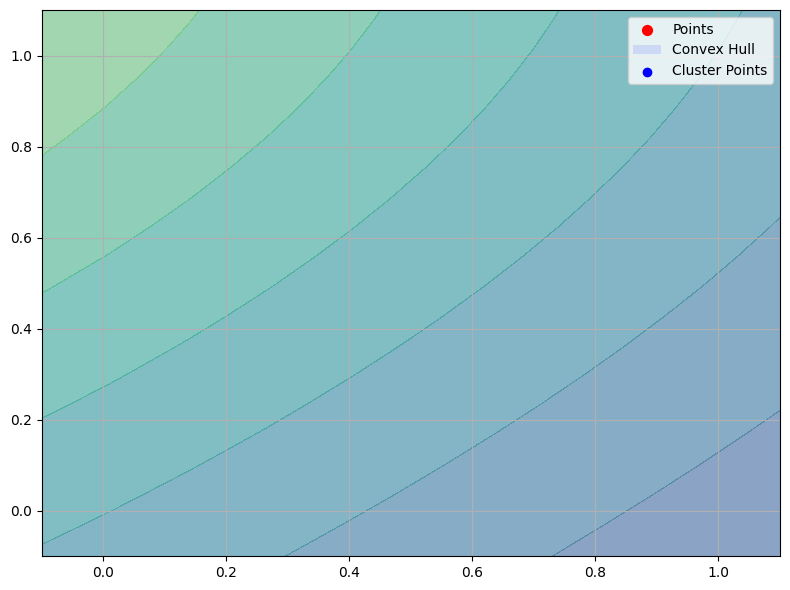

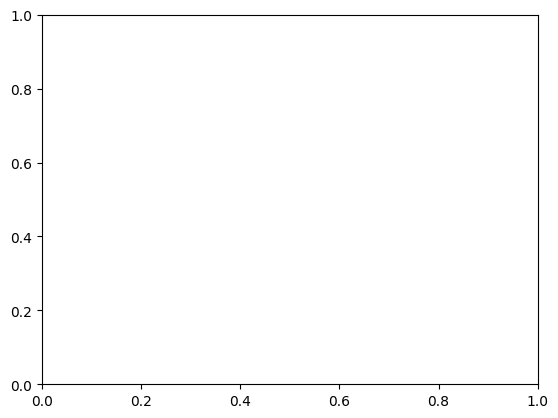

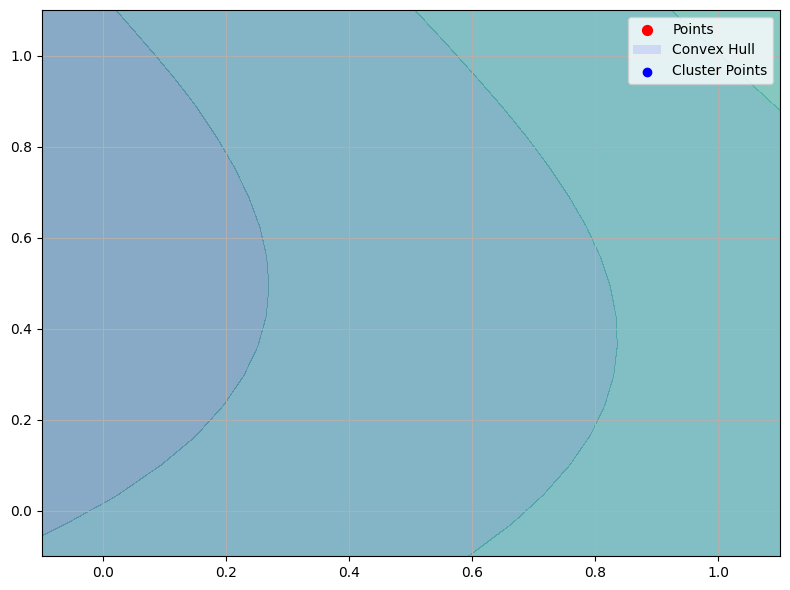

In [17]:
# Filter out rows without convex hull area
filtered_df = results_df.dropna(subset=['Convex_Hull_Area'])

# Get the least and most uncertain instances
least_uncertain = filtered_df.nsmallest(3, 'Convex_Hull_Area')
most_uncertain = filtered_df.nlargest(3, 'Convex_Hull_Area')

# Plot the least uncertain instances
for i, (_, row) in enumerate(least_uncertain.iterrows()):
    q = "Image == '" + row['Image'] + "'"
    tmp_df = data.query(q)
    texts = tmp_df.values[0][1:]
    
    embeddings = np.array([get_bert_embeddings(text) for text in texts if pd.notnull(text)])
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)
    dbscan = DBSCAN(eps=7.0, min_samples=3)
    labels = dbscan.fit_predict(embeddings_2d)
    
    fig_name = f'least_uncertain_{i+1}.pdf'
    
    plot_clusters_plt(embeddings_2d, labels, row['Image'], row['Convex_Hull_Area'], fig_name)

# Plot the most uncertain instances
for i, (_, row) in enumerate(most_uncertain.iterrows()):
    tmp_df = data.query("Image == '" + row['Image'] + "'")
    
    texts = tmp_df.values[0][1:]
    
    embeddings = np.array([get_bert_embeddings(text) for text in texts if pd.notnull(text)])
    
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)
    dbscan = DBSCAN(eps=5.0, min_samples=3)
    labels = dbscan.fit_predict(embeddings_2d)
    
    # Save each subplot to a separate PDF
    individual_fig = plt.figure()
    ax = individual_fig.add_subplot(111)
    
    fig_name = f'most_uncertain_{i+1}.pdf'
    
    plot_clusters_plt(embeddings_2d, labels, row['Image'], row['Convex_Hull_Area'], fig_name)


An exception occurred


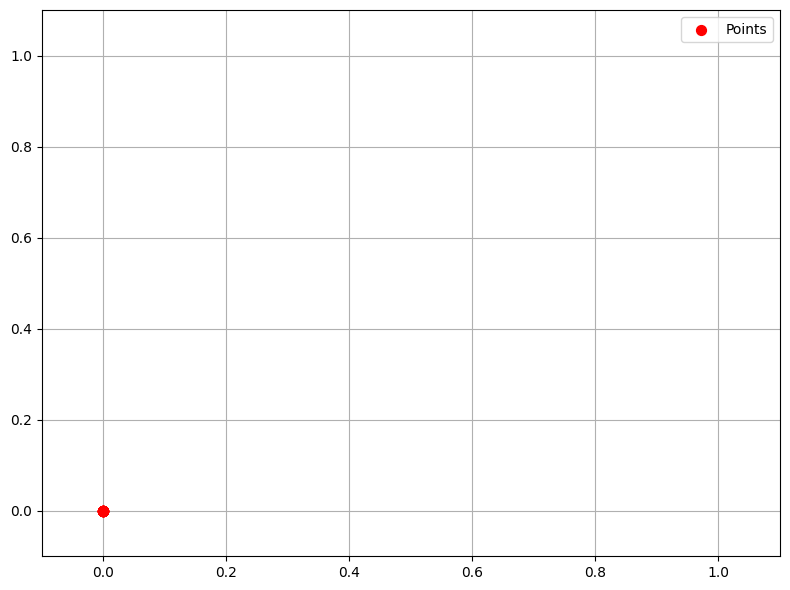

An exception occurred


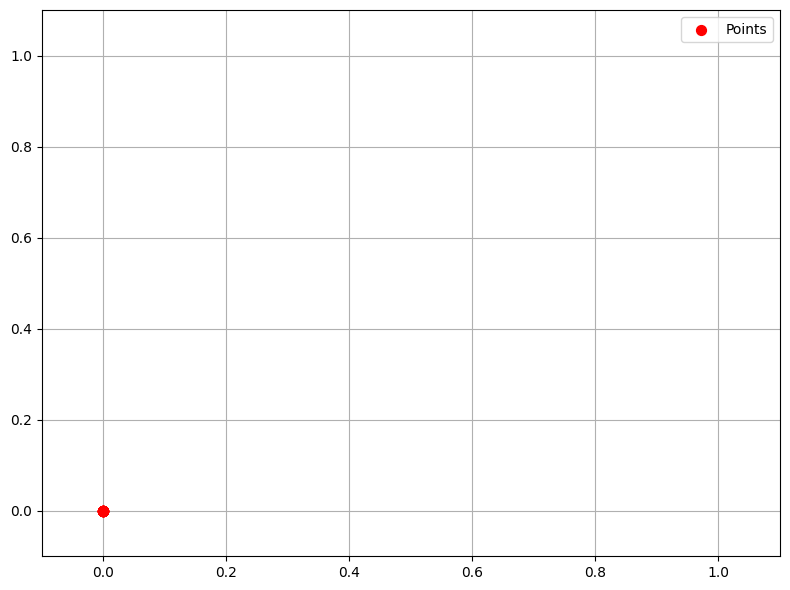

An exception occurred


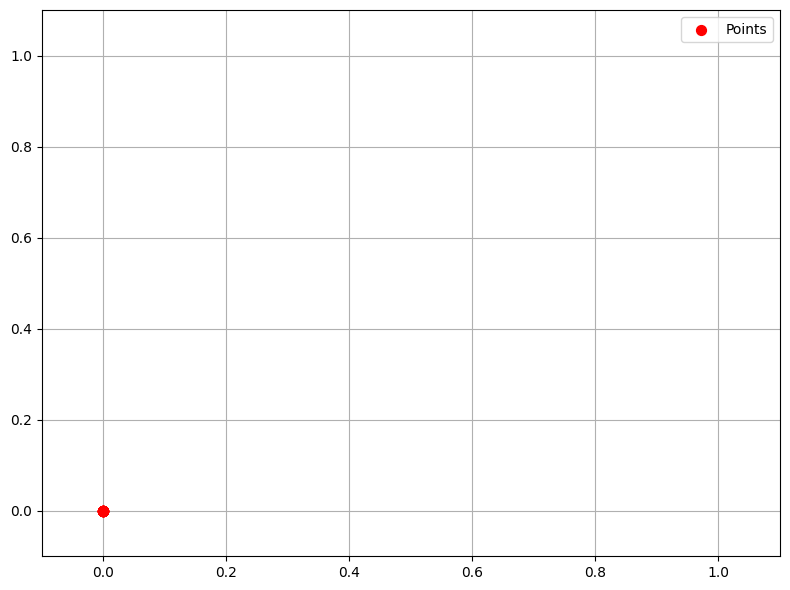

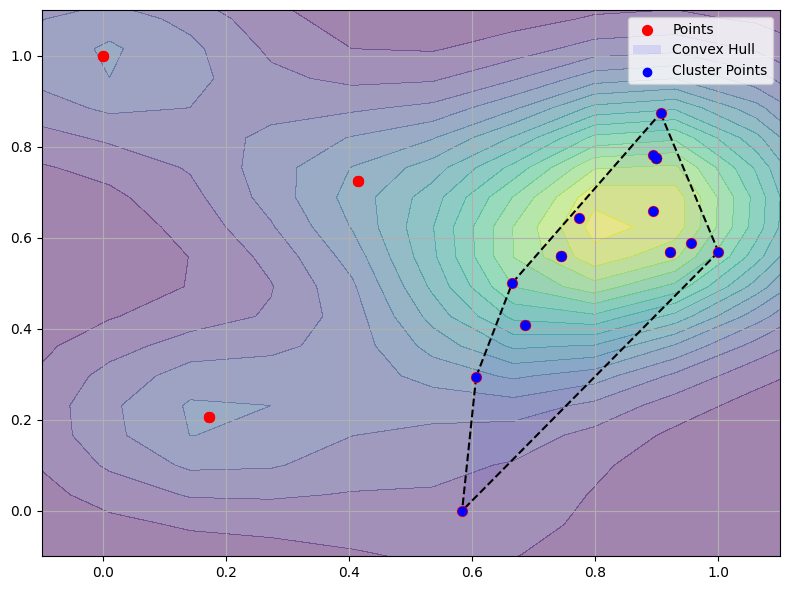

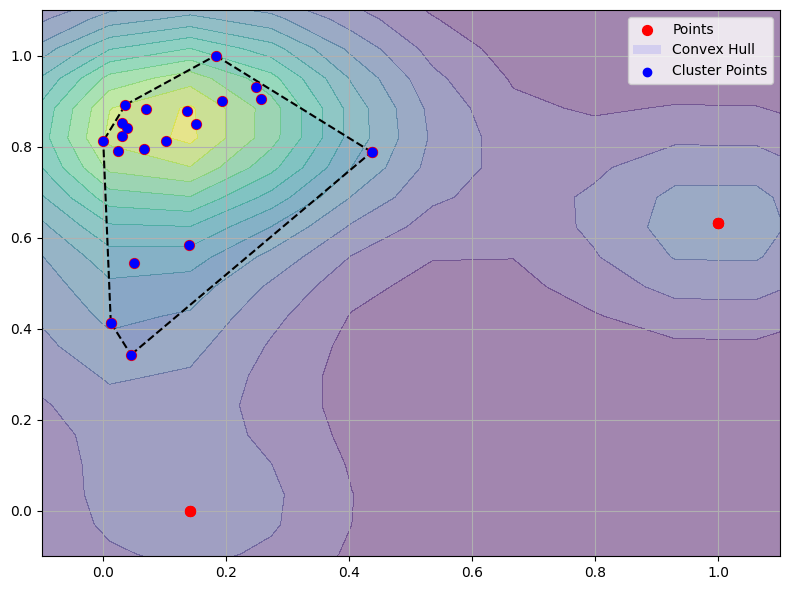

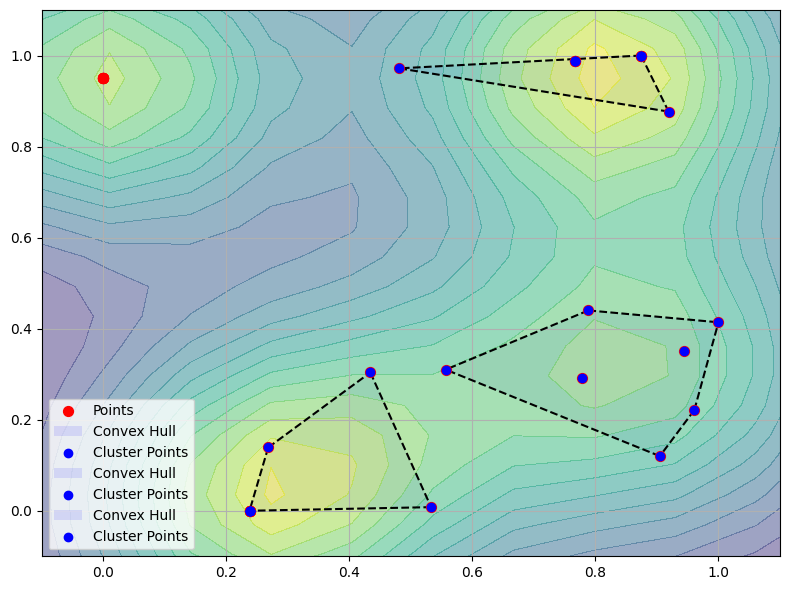

In [18]:
from sklearn.preprocessing import MinMaxScaler

# Filter out rows without convex hull area
filtered_df = results_df.dropna(subset=['Convex_Hull_Area'])

# Get the least and most uncertain instances
least_uncertain = filtered_df.nsmallest(3, 'Convex_Hull_Area')
most_uncertain = filtered_df.nlargest(3, 'Convex_Hull_Area')

# Function to normalize embeddings
def normalize_embeddings(embeddings_2d):
    scaler = MinMaxScaler()
    return scaler.fit_transform(embeddings_2d)

# Plot the least uncertain instances
for i, (_, row) in enumerate(least_uncertain.iterrows()):
    q = "Image == '" + row['Image'] + "'"
    tmp_df = data.query(q)
    texts = tmp_df.values[0][1:]
    
    embeddings = np.array([get_bert_embeddings(text) for text in texts if pd.notnull(text)])
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)
    
    # Normalize embeddings
    embeddings_2d = normalize_embeddings(embeddings_2d)
    
    dbscan = DBSCAN(eps=0.3, min_samples=5)
    labels = dbscan.fit_predict(embeddings_2d)
    
    fig_name = f'least_uncertain_{i+1}.pdf'
    
    plot_clusters_plt(embeddings_2d, labels, row['Image'], row['Convex_Hull_Area'], fig_name)

# Plot the most uncertain instances
for i, (_, row) in enumerate(most_uncertain.iterrows()):
    tmp_df = data.query("Image == '" + row['Image'] + "'")
    
    texts = tmp_df.values[0][1:]
    
    embeddings = np.array([get_bert_embeddings(text) for text in texts if pd.notnull(text)])
    
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)
    
    # Normalize embeddings
    embeddings_2d = normalize_embeddings(embeddings_2d)
    
    dbscan = DBSCAN(eps=0.3, min_samples=5)
    labels = dbscan.fit_predict(embeddings_2d)
    
    fig_name = f'most_uncertain_{i+1}.pdf'
    
    plot_clusters_plt(embeddings_2d, labels, row['Image'], row['Convex_Hull_Area'], fig_name)


In [25]:
results_df

,Image,Num_Clusters,Convex_Hull_Area,Cluster_Areas
0,000001-1.jpg,1.0,2.639844e+01,[26.398441547673208]
1,000001-1.png,1.0,1.674359e+01,[16.74359344869947]
2,000001-10.jpg,1.0,1.811903e+01,[18.11903484795215]
3,000001-11.jpg,1.0,2.005623e+01,[20.05622635467627]
4,000001-12.jpg,2.0,5.157770e-07,[5.157770158012087e-07]
...,...,...,...,...
925,wong-0004.jpg,1.0,0.000000e+00,[]
926,wong-0005.jpg,1.0,3.175804e+01,[31.7580358588538]
927,yxppt-2020-02-19_00-51-27_287214-day10.jpg,1.0,3.703742e-12,[3.70374153724186e-12]
928,yxppt-2020-02-19_00-51-27_287214-day12.jpg,1.0,1.855132e+01,[18.551324222612415]


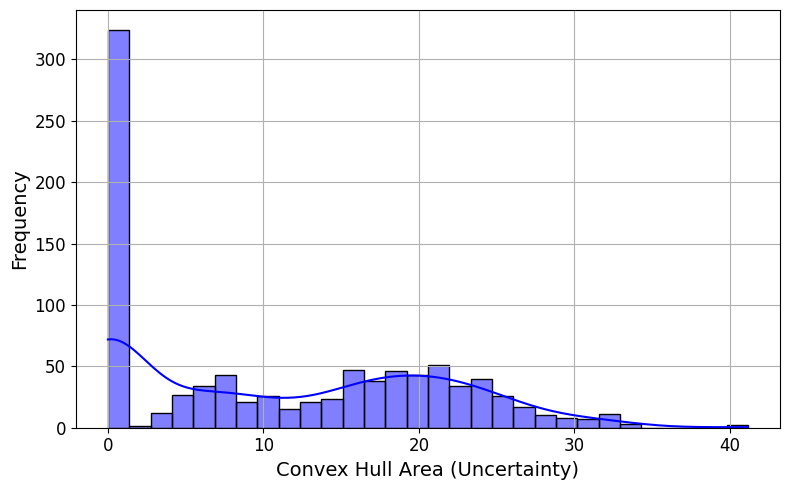

In [24]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(results_df['Convex_Hull_Area'], bins=30, kde=True, color='blue')
#plt.title('Distribution of Convex Hull Areas (Uncertainty)', fontsize=18)
plt.xlabel('Convex Hull Area (Uncertainty)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig('uncertainty_distribution.pdf', bbox_inches='tight')
plt.show()

In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Load your DataFrames (assuming they are already loaded as results_df and data)
# If not, you should load them appropriately using pd.read_csv or other means

# Ensure that the 'Image' column in both DataFrames match correctly
# This step assumes you have a way to match images to responses, you should replace this with actual logic
data['Image'] = results_df['Image']

# Define the image folder
image_folder = 'covid-chestxray-dataset/images/'
output_folder = 'output_images_responses'

# Create the output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Sort the DataFrame by Convex_Hull_Area in descending order and get the top 3
top_images_df = results_df.sort_values(by='Convex_Hull_Area', ascending=False).head(3)

# Extract the corresponding responses for the top images
top_responses = []
for image in top_images_df['Image']:
    q = "Image =='" + image + "'"
    matched_data = data.query(q)
    if not matched_data.empty:
        image_responses = matched_data.iloc[:, :-1].values.flatten()  # Exclude the 'Image' column
        if len(image_responses) > 0:
            top_responses.append((image, image_responses[:30]))  # Taking the first 30 responses

# Plotting and saving the results
for i, (image, responses) in enumerate(top_responses):
    img_path = os.path.join(image_folder, image)
    
    # Check if the image file exists
    if not os.path.exists(img_path):
        print(f"Image file not found: {img_path}")
        continue
    
    # Load and display the image
    img = Image.open(img_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    
    # Save the image with responses as a PNG file
    img_save_path = os.path.join(output_folder, f'top_uncertain_image_{i+1}.png')
    plt.savefig(img_save_path, bbox_inches='tight', pad_inches=0)
    plt.close()

    # Save the corresponding responses to a text file
    responses_text = "\n-- ".join(responses)
    responses_save_path = os.path.join(output_folder, f'top_uncertain_responses_{i+1}.txt')
    with open(responses_save_path, 'w') as f:
        f.write(f"Image: {image}\n\nResponses:\n-- {responses_text}\n")
    
    print(f"Saved image and responses for: {image}")

# Output the locations of saved files
print(f"Images and responses saved in: {output_folder}")


Image file not found: covid-chestxray-dataset/images/000002-6.jpg
Image file not found: covid-chestxray-dataset/images/000006-12.jpg
Image file not found: covid-chestxray-dataset/images/000010-5.jpg
Images and responses saved in: output_images_responses


In [21]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Load your DataFrames (assuming they are already loaded as results_df and data)
# If not, you should load them appropriately using pd.read_csv or other means

# Ensure that the 'Image' column in both DataFrames match correctly
# This step assumes you have a way to match images to responses, you should replace this with actual logic
data['Image'] = results_df['Image']

# Define the image folder
image_folder = 'covid-chestxray-dataset/images/'
output_folder = 'output_images_responses'

# Create the output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Sort the DataFrame by Convex_Hull_Area in descending order and get the last 3
top_images_df = results_df.sort_values(by='Convex_Hull_Area', ascending=True).head(3)

# Extract the corresponding responses for the top images
top_responses = []
for image in top_images_df['Image']:
    q = "Image =='" + image + "'"
    matched_data = data.query(q)
    if not matched_data.empty:
        image_responses = matched_data.iloc[:, :-1].values.flatten()  # Exclude the 'Image' column
        if len(image_responses) > 0:
            top_responses.append((image, image_responses[:30]))  # Taking the first 30 responses

# Plotting and saving the results
for i, (image, responses) in enumerate(top_responses):
    img_path = os.path.join(image_folder, image)
    
    # Check if the image file exists
    if not os.path.exists(img_path):
        print(f"Image file not found: {img_path}")
        continue
    
    # Load and display the image
    img = Image.open(img_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    
    # Save the image with responses as a PNG file
    img_save_path = os.path.join(output_folder, f'least_uncertain_image_{i+1}.png')
    plt.savefig(img_save_path, bbox_inches='tight', pad_inches=0)
    plt.close()

    # Save the corresponding responses to a text file
    responses_text = "\n-- ".join(responses)
    responses_save_path = os.path.join(output_folder, f'least_uncertain_responses_{i+1}.txt')
    with open(responses_save_path, 'w') as f:
        f.write(f"Image: {image}\n\nResponses:\n-- {responses_text}\n")
    
    print(f"Saved image and responses for: {image}")

# Output the locations of saved files
print(f"Images and responses saved in: {output_folder}")


Image file not found: covid-chestxray-dataset/images/8da14fff.jpg
Image file not found: covid-chestxray-dataset/images/fff13f3a.jpg
Image file not found: covid-chestxray-dataset/images/16689_1_6.jpg
Images and responses saved in: output_images_responses


In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Load your DataFrames (assuming they are already loaded as results_df and data)
# If not, you should load them appropriately using pd.read_csv or other means

# Ensure that the 'Image' column in both DataFrames match correctly
# This step assumes you have a way to match images to responses, you should replace this with actual logic
data['Image'] = results_df['Image']

# Define the image folder
image_folder = 'covid-chestxray-dataset/images/'

# Sort the DataFrame by Convex_Hull_Area in descending order and get the top 5
top_images_df = results_df.sort_values(by='Convex_Hull_Area', ascending=False).head(5)

# Extract the corresponding responses for the top images
top_responses = []
for image in top_images_df['Image']:
    q = "Image =='" + image + "'"
    matched_data = data.query(q)
    if not matched_data.empty:
        image_responses = matched_data.iloc[:, :-1].values.flatten()  # Exclude the 'Image' column
        if len(image_responses) > 0:
            top_responses.append((image, image_responses[:30]))  # Taking the first 30 responses

idx_img = 0
# Plotting the results
for image, responses in top_responses:
    img_path = os.path.join(image_folder, image)
    
    # Check if the image file exists
    if not os.path.exists(img_path):
        print(f"Image file not found: {img_path}")
        continue
    
    # Load and display the image
    img = Image.open(img_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    #plt.title(f"Image: {image}", fontsize=14)
    plt.tight_layout()
    plt.savefig(f"low-{idx_img}-{image}",bbox_inches='tight')
    plt.show()
    
    print(f"Image: {image}")
    responses_text = "\n-- ".join(responses)
    print(responses_text)
    
    f = open(f"low-{idx_img}-{image}.txt")
    f.write(responses_text)
    f.close
    
    idx_img += 1

Image file not found: covid-chestxray-dataset/images/000002-6.jpg
Image file not found: covid-chestxray-dataset/images/000006-12.jpg
Image file not found: covid-chestxray-dataset/images/000010-5.jpg
Image file not found: covid-chestxray-dataset/images/1-s2.0-S0929664620300449-gr3_lrg-d.jpg
Image file not found: covid-chestxray-dataset/images/503d2fbe68cd143b0f15749b4f816b_jumbo.jpeg


## Credible/Prediction Intervals Visualization
This visualization shows the range within which predictions fall with a certain probability (e.g., 95% credible interval).

In [23]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from scipy.spatial import ConvexHull
from sklearn.preprocessing import MinMaxScaler

# List of CSV files corresponding to different conditions
csv_files = {
    '0.001_all': 'inference_total_0.001_all.csv',
    '25_all': 'inference_total_0.25_all_2.csv',
    '50_all': 'inference_total_50_all.csv',
    '75_all': 'inference_total_75_all.csv',
    '100_all': 'inference_total_100_all.csv'
}

# Initialize a DataFrame to store all results
all_results = pd.DataFrame()

def normalize_embeddings(embeddings_2d):
    scaler = MinMaxScaler()
    return scaler.fit_transform(embeddings_2d)

def process_csv(file_path, condition):
    # Read the CSV file with ';' as delimiter
    data = pd.read_csv(file_path, delimiter=";")
    
    # Remove unwanted characters from text fields and replace line feeds
    data.replace({r'[\[\]]': '', r'\n': ' ', r'\'': '', r'None': ''}, regex=True, inplace=True)
    
    # Transpose the DataFrame
    data = data.T
    
    # Reset the index and set new column names
    data.reset_index(drop=False, inplace=True)
    data.columns = ['Image'] + [f'Text_{i+1}' for i in range(data.shape[1] - 1)]
    
    # Initialize list to store results for this condition
    results = []

    for idx, row in tqdm(data.iterrows()):
        texts = row[1:].dropna().tolist()  # Assuming text columns start from index 1
        
        # Calculate embeddings for each text using a placeholder function
        embeddings = np.array([get_bert_embeddings(text) for text in texts])
        
        # Perform PCA for dimensionality reduction to 2D
        if embeddings.shape[0] < 10:
            continue
        pca = PCA(n_components=2)
        embeddings_2d = pca.fit_transform(embeddings)
        
        # Normalize embeddings
        embeddings_2d = normalize_embeddings(embeddings_2d)
        
        if embeddings_2d.shape[0] < 15:
            continue
        
        # Perform DBSCAN clustering
        dbscan = DBSCAN(eps=0.3, min_samples=5)
        labels = dbscan.fit_predict(embeddings_2d)
        
        unique_labels = set(labels)
        total_hull_area = 0
        
        for label in unique_labels:
            if label == -1:
                continue  # Ignore noise
            cluster_indices = np.where(labels == label)[0]
            cluster_points = embeddings_2d[cluster_indices]
            
            if len(np.unique(cluster_points, axis=0)) > 3:
                try:
                    hull = ConvexHull(cluster_points)
                    total_hull_area += hull.volume
                except:
                    print("An exception occurred")
        
        # Store the result for this image
        results.append({
            'Image': row['Image'],
            'Condition': condition,
            'Convex_Hull_Area': total_hull_area
        })

    return pd.DataFrame(results)

# Process each CSV file
for condition, file_path in tqdm(csv_files.items()):
    condition_results = process_csv(file_path, condition)
    print(f"Results for condition '{condition}':")
    print(condition_results)
    all_results = pd.concat([all_results, condition_results], ignore_index=True)

# Pivot the results to compare conditions side-by-side for each image
comparison_df = all_results.pivot(index='Image', columns='Condition', values='Convex_Hull_Area')

  0%|          | 0/5 [00:00<?, ?it/s]

0it [00:00, ?it/s]

KeyboardInterrupt: 

In [ ]:
comparison_df

Condition,0.001_all,100_all,25_all,50_all,75_all
Image,,,,,
000001-1.jpg,0.0,0.181254,0.022403,0.200073,0.615519
000001-1.png,0.0,0.262261,0.029840,0.139909,0.551298
000001-10.jpg,0.0,0.224636,0.096780,0.383863,0.235435
000001-11.jpg,0.0,0.208005,0.000000,0.177506,0.269727
000001-12.jpg,0.0,0.408722,0.000000,0.000000,0.230419
...,...,...,...,...,...
wong-0004.jpg,0.0,0.220884,0.000000,0.288925,0.402783
wong-0005.jpg,0.0,0.320911,0.287265,0.290328,0.201290
yxppt-2020-02-19_00-51-27_287214-day10.jpg,0.0,0.212705,0.000000,0.018934,0.059617


In [ ]:
# Calculate statistics for each condition
summary_stats = comparison_df.describe().T[['mean', 'count', 'std', 'min', 'max']]
summary_stats.rename(columns={'50%': 'median'}, inplace=True)

# Optionally, save the summary table to a CSV file
summary_stats.to_csv('comparison_of_uncertainty_across_conditions.csv')

summary_stats

,mean,count,std,min,max
Condition,,,,,
0.001_all,0.000078,930.0,0.001082,0.0,0.023171
100_all,0.311707,930.0,0.144161,0.0,0.725738
25_all,0.118869,930.0,0.172579,0.0,0.720256
50_all,0.169836,930.0,0.167945,0.0,0.742153
75_all,0.247290,930.0,0.173386,0.0,0.783125


In [ ]:
# Convert the summary_stats DataFrame to LaTeX format
latex_table = summary_stats.to_latex(index=True, float_format="%.6f")

# Print the LaTeX table
print(latex_table)

\begin{tabular}{lrrrrr}
\toprule
 & mean & count & std & min & max \\
Condition &  &  &  &  &  \\
\midrule
0.001_all & 0.000078 & 930.000000 & 0.001082 & 0.000000 & 0.023171 \\
100_all & 0.311707 & 930.000000 & 0.144161 & 0.000000 & 0.725738 \\
25_all & 0.118869 & 930.000000 & 0.172579 & 0.000000 & 0.720256 \\
50_all & 0.169836 & 930.000000 & 0.167945 & 0.000000 & 0.742153 \\
75_all & 0.247290 & 930.000000 & 0.173386 & 0.000000 & 0.783125 \\
\bottomrule
\end{tabular}



In [ ]:
# Calculate a detailed statistical summary for each condition
detailed_stats = comparison_df.describe(percentiles=[.1, .25, .5, .75, .9]).T[['count', 'mean', 'std', 'min', '10%', '25%', '50%', '75%', '90%', 'max']]

# Transpose the table
transposed_stats = detailed_stats.T

# Display the transposed table (with 10-20 rows)
transposed_stats

# Optionally, save the transposed table to a CSV file
transposed_stats.to_csv('transposed_detailed_comparison_statistics.csv')

# Optionally, save the table to LaTeX format
latex_transposed_stats = transposed_stats.to_latex(index=True, float_format="%.6f")
print(latex_transposed_stats)


\begin{tabular}{lrrrrr}
\toprule
Condition & 0.001_all & 100_all & 25_all & 50_all & 75_all \\
\midrule
count & 930.000000 & 930.000000 & 930.000000 & 930.000000 & 930.000000 \\
mean & 0.000078 & 0.311707 & 0.118869 & 0.169836 & 0.247290 \\
std & 0.001082 & 0.144161 & 0.172579 & 0.167945 & 0.173386 \\
min & 0.000000 & 0.000000 & 0.000000 & 0.000000 & 0.000000 \\
10% & 0.000000 & 0.131133 & 0.000000 & 0.000000 & 0.005224 \\
25% & 0.000000 & 0.212275 & 0.000000 & 0.000000 & 0.101901 \\
50% & 0.000000 & 0.301865 & 0.022638 & 0.138926 & 0.235899 \\
75% & 0.000000 & 0.407283 & 0.195234 & 0.286987 & 0.369799 \\
90% & 0.000000 & 0.513088 & 0.383664 & 0.414961 & 0.490810 \\
max & 0.023171 & 0.725738 & 0.720256 & 0.742153 & 0.783125 \\
\bottomrule
\end{tabular}



In [ ]:
transposed_stats

Condition,0.001_all,100_all,25_all,50_all,75_all
count,930.000000,930.000000,930.000000,930.000000,930.000000
mean,0.000078,0.311707,0.118869,0.169836,0.247290
std,0.001082,0.144161,0.172579,0.167945,0.173386
min,0.000000,0.000000,0.000000,0.000000,0.000000
10%,0.000000,0.131133,0.000000,0.000000,0.005224
25%,0.000000,0.212275,0.000000,0.000000,0.101901
50%,0.000000,0.301865,0.022638,0.138926,0.235899
75%,0.000000,0.407283,0.195234,0.286987,0.369799
90%,0.000000,0.513088,0.383664,0.414961,0.490810
max,0.023171,0.725738,0.720256,0.742153,0.783125


In [ ]:
summary_stats

,mean,count,std,min,max
Condition,,,,,
0.001_all,0.000078,930.0,0.001082,0.0,0.023171
100_all,0.311707,930.0,0.144161,0.0,0.725738
25_all,0.118869,930.0,0.172579,0.0,0.720256
50_all,0.169836,930.0,0.167945,0.0,0.742153
75_all,0.247290,930.0,0.173386,0.0,0.783125


In [ ]:
# Calculate additional percentiles
percentiles = comparison_df.describe(percentiles=[.1, .25, .5, .75, .9, .95]).T
percentiles

,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
Condition,,,,,,,,,,,
0.001_all,930.0,0.000078,0.001082,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.023171
100_all,930.0,0.311707,0.144161,0.0,0.131133,0.212275,0.301865,0.407283,0.513088,0.569037,0.725738
25_all,930.0,0.118869,0.172579,0.0,0.000000,0.000000,0.022638,0.195234,0.383664,0.547399,0.720256
50_all,930.0,0.169836,0.167945,0.0,0.000000,0.000000,0.138926,0.286987,0.414961,0.490489,0.742153
75_all,930.0,0.247290,0.173386,0.0,0.005224,0.101901,0.235899,0.369799,0.490810,0.559771,0.783125


In [ ]:
# Calculate IQR (Interquartile Range)
Q1 = comparison_df.quantile(0.25)
Q3 = comparison_df.quantile(0.75)
IQR = Q3 - Q1

# Identify outliers (beyond 1.5 * IQR)
outliers = comparison_df[((comparison_df < (Q1 - 1.5 * IQR)) | (comparison_df > (Q3 + 1.5 * IQR))).any(axis=1)]
outliers


Condition,0.001_all,100_all,25_all,50_all,75_all
Image,,,,,
000002-3.jpg,0.000000e+00,0.401181,0.571479,0.642903,0.588686
000009.jpg,0.000000e+00,0.316200,0.638572,0.276944,0.715610
000010-5.jpg,1.776357e-15,0.375815,0.158352,0.511010,0.478419
00870a9c.jpg,0.000000e+00,0.421814,0.590509,0.146275,0.184059
08ed451c576ee00935ee178ec85c57_jumbo-1.jpeg,1.389422e-02,0.242945,0.321680,0.216025,0.281912
...,...,...,...,...,...
nejmc2001573_f1b.jpeg,0.000000e+00,0.157764,0.665602,0.205464,0.202796
nejmoa2001017_f1-a.png,5.243006e-03,0.538119,0.591043,0.194713,0.240956
paving.jpg,0.000000e+00,0.262168,0.669469,0.123895,0.162061


In [ ]:
# Calculate correlation matrix
correlation_matrix = comparison_df.corr()
correlation_matrix


Condition,0.001_all,100_all,25_all,50_all,75_all
Condition,,,,,
0.001_all,1.000000,-0.000630,0.097804,0.069517,0.018654
100_all,-0.000630,1.000000,0.038524,0.156722,0.282732
25_all,0.097804,0.038524,1.000000,0.528693,0.234974
50_all,0.069517,0.156722,0.528693,1.000000,0.512028
75_all,0.018654,0.282732,0.234974,0.512028,1.000000


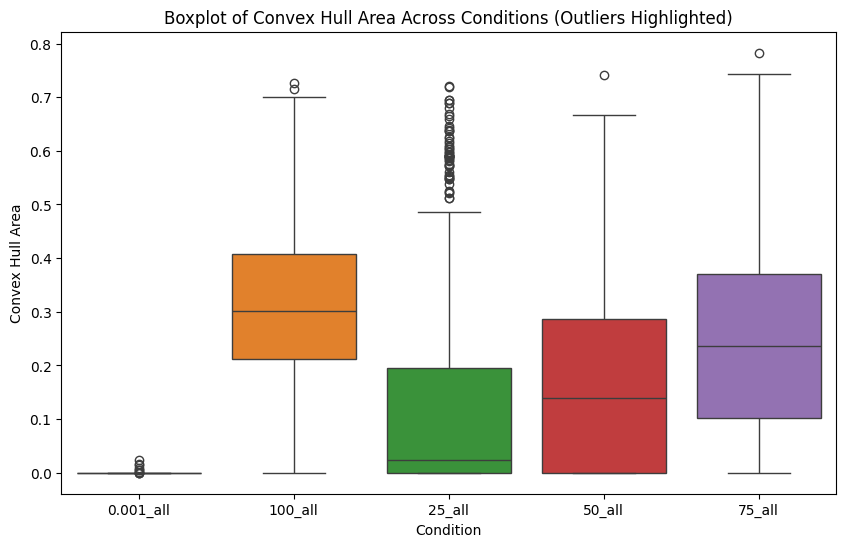

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a boxplot to visualize the distribution and outliers for each condition
plt.figure(figsize=(10, 6))
sns.boxplot(data=comparison_df)

# Add title and labels
plt.title('Boxplot of Convex Hull Area Across Conditions (Outliers Highlighted)')
plt.xlabel('Condition')
plt.ylabel('Convex Hull Area')

# Show the plot
plt.show()


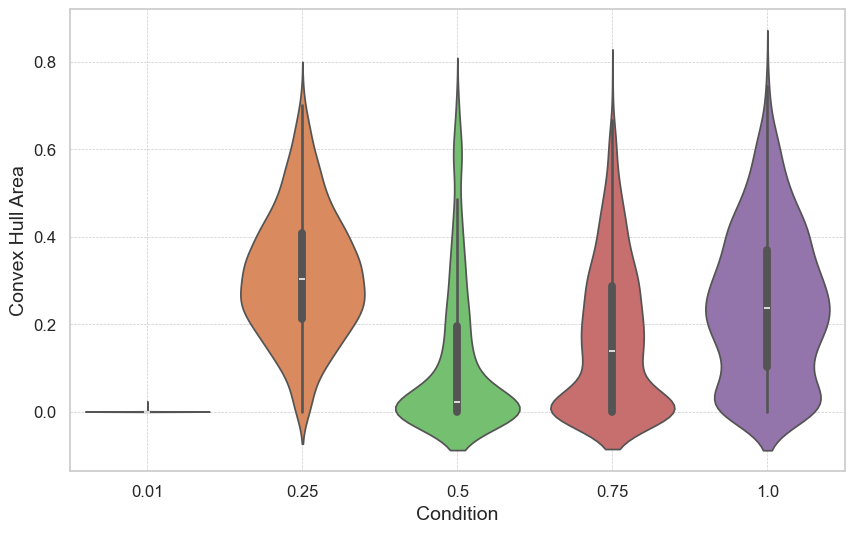

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the general style for the plot
sns.set(style="whitegrid")

# Create the violin plot with enhanced settings
plt.figure(figsize=(10, 6))

# Violin plot with boxplot inside
sns.violinplot(data=comparison_df, inner="box", palette="muted")

# Set title and labels with larger fonts for publication
# plt.title('Convex Hull Area Distribution Across Conditions', fontsize=16, weight='bold')
plt.xlabel('Condition', fontsize=14)
plt.ylabel('Convex Hull Area', fontsize=14)

# Increase the size of tick labels for readability
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add gridlines for better visibility
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Manually set the x-tick labels
plt.xticks(ticks=range(len(comparison_df.columns)), labels=[0.01, 0.25, 0.5, 0.75, 1.0], fontsize=12)


# Save the plot as a high-resolution image suitable for publication
# plt.savefig('convex_hull_area_violin_plot.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


In [ ]:
from scipy.stats import skew, kurtosis

# Add skewness and kurtosis
skewness = comparison_df.skew()
kurt = comparison_df.kurt()

summary_stats['skewness'] = skewness
summary_stats['kurtosis'] = kurt

summary_stats

,mean,count,std,min,max,skewness,kurtosis
Condition,,,,,,,
0.001_all,0.000078,930.0,0.001082,0.0,0.023171,16.515709,299.280973
100_all,0.311707,930.0,0.144161,0.0,0.725738,0.265688,-0.245027
25_all,0.118869,930.0,0.172579,0.0,0.720256,1.576351,1.653158
50_all,0.169836,930.0,0.167945,0.0,0.742153,0.763671,-0.281227
75_all,0.247290,930.0,0.173386,0.0,0.783125,0.371054,-0.573596


In [ ]:
import pandas as pd
from scipy.stats import pearsonr

# Calculate the mean Convex Hull Area per image
mean_per_image = comparison_df.mean(axis=1)

# Initialize lists to store correlation coefficients and p-values
correlations = []
p_values = []

# Loop through each condition and calculate the Pearson correlation and p-value
for condition in comparison_df.columns:
    # Calculate correlation and p-value between the mean per image and each condition's values
    corr, p_value = pearsonr(mean_per_image, comparison_df[condition])
    
    # Append the results to the lists
    correlations.append(corr)
    p_values.append(p_value)

# Create a DataFrame to store the results
correlation_df = pd.DataFrame({
    'Condition': comparison_df.columns,
    'Correlation': correlations,
    'P-value': p_values
})

# Display the correlation and p-value table
correlation_df


,Condition,Correlation,P-value
0,0.001_all,0.072033,2.804721e-02
1,100_all,0.496978,3.602504e-59
2,25_all,0.676342,2.353224e-125
3,50_all,0.814485,1.249801e-221
4,75_all,0.748725,6.841876e-168
